# Find TC genesis times
This notebook uses wave-following max winds associated with each ensemble member, from save_maxwind_wave_following.ipynb, to determine when TC genesis occurs. 

Couple of citations: stackoverflow and geeksforgeeks
https://www.geeksforgeeks.org/python/python-last-occurrence-of-some-element-in-a-list/
https://stackoverflow.com/a/14184904


In [1]:
from __future__ import print_function
import pkg_resources
import os
#from os import listdir
#from os.path import isfile, join
import glob
import metpy
import subprocess
import wrf
import numpy as np
from netCDF4 import Dataset
import numpy.ma as ma

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib.cbook as cbook
import cartopy.crs as crs
import cartopy.feature as cfeature
from metpy.units import units

from cartopy.feature import NaturalEarthFeature

from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches

import datetime
from matplotlib.dates import DateFormatter

from metpy.plots import ctables

import metpy.calc as mpcalc
import xarray as xr
import pandas as pd
import seaborn as sns

/glade/derecho/scratch/athornton/tmp/ipykernel_29283/3729603952.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [3]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[0]     # try: variation[1]
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot
#ens = init_times[3]

## 
if wave == 'main':
    name = 'Rene'
else:
    name = 'Paulette'

In [4]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [5]:
# This is a dummy variable 
# ensembles members without TCs will contain this value for TC genesis
# which will fall outside the range of plotting
no_tc_time = pd.to_datetime('2020-09-10 00:00')

In [6]:
## The following searches our mask for 8 values of False in a row,
## indicating that windspeeds are greater than 17.5 m/s for at least 24 hours.
## Structured based on code in last cell from stackoverflow
def find_tc_gen(mask, tc_strength_for_24hrs):
    for i in range(0, len(mask)):
        if list(mask.mask[i:i+8]) == tc_strength_for_24hrs:
            print('24 hours of TC strength winds detected. Index of genesis:',i)
            tc_gen = i
            break
    try:
        return tc_gen
    except UnboundLocalError:
        # if no TCs are present
        # append dummy time instead of TC genesis
        tc_gen = no_tc_time
        return tc_gen

In [7]:
## The following finds the last occurence of below TC strength winds
## https://www.geeksforgeeks.org/python/python-last-occurrence-of-some-element-in-a-list/
def find_tc_end(mask):
    for i in range(0, len(mask)):
        if mask.mask[i] == True:
            tc_gen_index_before = i
    return tc_gen_index_before

In [8]:
## The following implements the above functions to find TC genesis
def tropical_cyclones(set_name):
    # Empty list to store TCs in this ensemble group 
    # should be 9 in length
    tc_times = []
    # loop through all 9 initialization times
    for ens in init_times:
        save_name = set_name +"_"+ ens
        print(save_name)
        path_out = "/glade/u/home/athornton/qtrack/"+wave+"_wave/"
        file_out = path_out +wave+'_wave_max_winds_'+save_name+'.nc'
        
        # get max winds following the wave  
        df = xr.open_dataset(file_out)
        
        # Apply a mask to hide values less than TC strength
        mask = ma.masked_where(df.max_wind < 17.5, df.max_wind)
        
        # Construct a list to use to find 8 consecutive timesteps > 17.5 m/s
        # This corresponds to 24 hours of TC strength winds
        tc_strength_for_24hrs = [False]*8

        # Finds the first index within these 24 hours and labels as a TC
        index = find_tc_gen(mask, tc_strength_for_24hrs)
        
        start_time ='2020-09-'+ens[:2]+' '+ens[2:]+':00'
        end_time = '2020-09-09 12:00'
        time_list = pd.date_range(start_time, end_time, freq='3h')
        try:
            tc_times.append(time_list[index])
        except IndexError:
            # If TC genesis occurs near the end of the simulation
            # Assume TC genesis process will continue
            print('trying for TC gen at end of simulation...')
            if mask.mask[-1] == False:
                print('found TC strength winds at end of simulation')
                # get the index of the last True, which represents the last point below 17.5 m/s
                index = find_tc_end(mask)
                print(index)
                tc_times.append(time_list[index+1])
            else:
                print('no TC in this simulation')
                # append dummy time instead of TC genesis
                tc_times.append(no_tc_time)
    return tc_times

In [9]:
fluxon_tc = tropical_cyclones(variation[0])
rst_on24_tc = tropical_cyclones(variation[1])
rst_on36_tc = tropical_cyclones(variation[2])
rst_on48_tc = tropical_cyclones(variation[3])

fluxon_0300
trying for TC gen at end of simulation...
found TC strength winds at end of simulation
47
fluxon_0303
24 hours of TC strength winds detected. Index of genesis: 42
fluxon_0306
24 hours of TC strength winds detected. Index of genesis: 39
fluxon_0309
24 hours of TC strength winds detected. Index of genesis: 15
fluxon_0312
24 hours of TC strength winds detected. Index of genesis: 37
fluxon_0315
24 hours of TC strength winds detected. Index of genesis: 36
fluxon_0318
trying for TC gen at end of simulation...
found TC strength winds at end of simulation
44
fluxon_0321
24 hours of TC strength winds detected. Index of genesis: 34
fluxon_0400
trying for TC gen at end of simulation...
found TC strength winds at end of simulation
38
rst_on24_0300
trying for TC gen at end of simulation...
found TC strength winds at end of simulation
47
rst_on24_0303
trying for TC gen at end of simulation...
found TC strength winds at end of simulation
49
rst_on24_0306
trying for TC gen at end of simula

In [10]:
# Construct a dataframe to contain all TC genesis times across ensemble members and groups
tc_time = fluxon_tc,rst_on24_tc,rst_on36_tc,rst_on48_tc
tc_time = np.array(tc_time)
tc_time = tc_time.flatten()
g = ['fluxon','fluxon','fluxon',
     'fluxon','fluxon','fluxon',
     'fluxon','fluxon','fluxon',
    'rst_on24','rst_on24','rst_on24',
    'rst_on24','rst_on24','rst_on24',
    'rst_on24','rst_on24','rst_on24',
    'rst_on36','rst_on36','rst_on36',
    'rst_on36','rst_on36','rst_on36',
    'rst_on36','rst_on36','rst_on36',
    'rst_on48','rst_on48','rst_on48',
    'rst_on48','rst_on48','rst_on48',
    'rst_on48','rst_on48','rst_on48',]
df = pd.DataFrame({'tc_time':tc_time, 'run':g})

In [11]:
axis_dates_list = pd.date_range(start='2020-09-03 00:00:00', end='2020-09-10 00:00:00', freq='3h')

In [12]:
obs_tc = pd.to_datetime('2020-09-07 12:00')

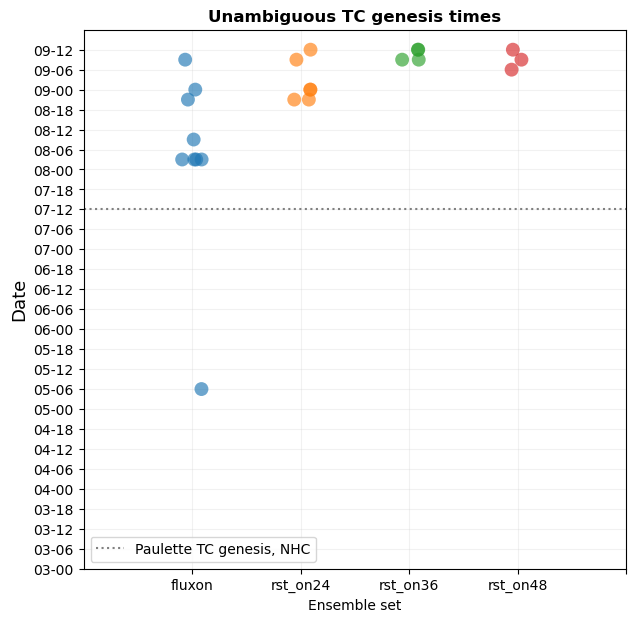

In [17]:
plt.rcParams['savefig.dpi'] = 255

fig, ax = plt.subplots(figsize=(7,7))
ar = np.arange(9) # just as an example array

ax.set_title('Unambiguous TC genesis times', size=12, weight='bold')
ax.set_ylabel('Date', size=13)
date_form = DateFormatter('%d-%H')
ax.yaxis.set_ticks(pd.date_range(axis_dates_list[0], axis_dates_list[-4], freq='6h'))
ax.yaxis.set_major_formatter(date_form)
ax.set_ylim(axis_dates_list[0],axis_dates_list[-3])
sns.stripplot(data=df, x='run', y='tc_time', hue='run', alpha=0.65, s=10)

ax.axhline(obs_tc, color='gray', label='Paulette TC genesis, NHC', linestyle=':')
ax.set_xticks(np.arange(9), variation)
ax.grid(color='lightgray',alpha=0.3)
ax.set_xlabel('Ensemble set')
ax.set_xlim(-1,4)
plt.legend()
plt.savefig(plotsdir+'unambig_tc_time.png')

In [221]:
# Source - https://stackoverflow.com/a/14184904
# Posted by Stuart
# Retrieved 2026-08-29, License - CC BY-SA 3.0

# def five_true(L):
#     for i in range(len(L) - 5):
#         if L[i:i + 5] == [True] * 5:
#             return True
#     return False
